Treino → todo o histórico até 2026-06-10 (df_train.csv já construído)
Teste/Backtesting → jogos do Mundial 2026 que já têm resultado real, ou seja, linhas do df_full.csv onde:

tournament == "FIFA World Cup"
date >= 2026-06-11
home_score.notna() (resultado já conhecido)

Este split é mais honesto do que um split aleatório porque respeita a ordem temporal — o modelo nunca viu estes jogos durante o treino: validação em dados reais do torneio em curso.

### NOTA: Este notebook é o modelo baseline V1.
### Usa Diff_Ranking que foi substituído por Diff_Points no V4. Para reproduzir, restaurar df_train.csv com Diff_Ranking ou substituir "Diff_Ranking" por "Diff_Points" nas FEATURES.
### O modelo em produção é o 04d_model_training_v4.ipynb

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, log_loss
)
import joblib




In [ ]:

# --- 1. Carregar dados ---
df_train = pd.read_csv("../data/df_train.csv")
df_full  = pd.read_csv("../data/df_full.csv")
df_full["date"] = pd.to_datetime(df_full["date"])

# --- 2. Conjunto de teste (dinâmico) ---
df_test = df_full[
    (df_full["tournament"] == "FIFA World Cup") &
    (df_full["date"] >= "2026-06-11") &
    (df_full["home_score"].notna())
].copy()

print(f"Treino:  {len(df_train)} jogos")
print(f"Teste:   {len(df_test)} jogos")

# --- 3. Definir features e targets ---
FEATURES = [
    "Diff_Ranking",
    "Fator_Casa",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away",
    "Tipo_Competicao",
]

X_train = df_train[FEATURES]
y_clf   = df_train["Resultado"]
y_reg_home = df_train["home_score"]
y_reg_away = df_train["away_score"]

X_test  = df_test[FEATURES]
y_test  = df_test.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)

print(f"\nDistribuição target treino:\n{y_clf.value_counts()}")
print(f"\nDistribuição target teste:\n{y_test.value_counts()}")

# --- 4. Preprocessador ---
preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(handle_unknown="ignore"), ["Tipo_Competicao"])
], remainder="passthrough")

Treino:  45517 jogos
Teste:   28 jogos


KeyError: "['Diff_Ranking'] not in index"

C:\Users\hdlop\AppData\Local\Temp\ipykernel_8112\2361077174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_train.index, y=dist_train.values, ax=ax[0], palette=["red", "green", "orange"])


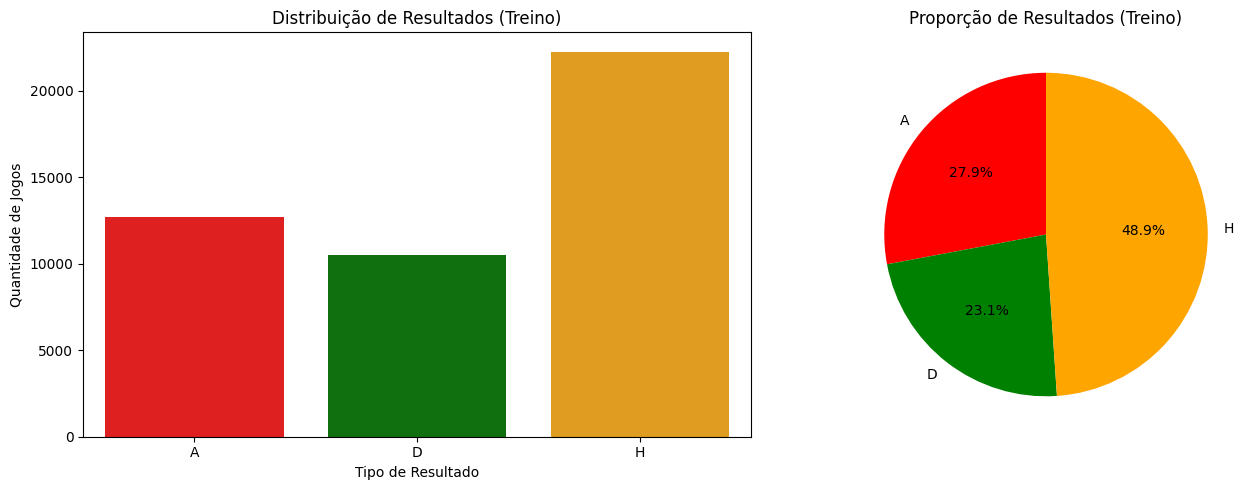

In [ ]:
# --- Distribuição treino ---
dist_train = y_clf.value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=dist_train.index, y=dist_train.values, ax=ax[0], palette=["red", "green", "orange"])
ax[0].set_title("Distribuição de Resultados (Treino)")
ax[0].set_xlabel("Tipo de Resultado")
ax[0].set_ylabel("Quantidade de Jogos")

# Pie chart
ax[1].pie(dist_train.values, labels=dist_train.index, autopct="%1.1f%%",
          colors=["red", "green", "orange"], startangle=90)
ax[1].set_title("Proporção de Resultados (Treino)")

plt.tight_layout()
plt.show()


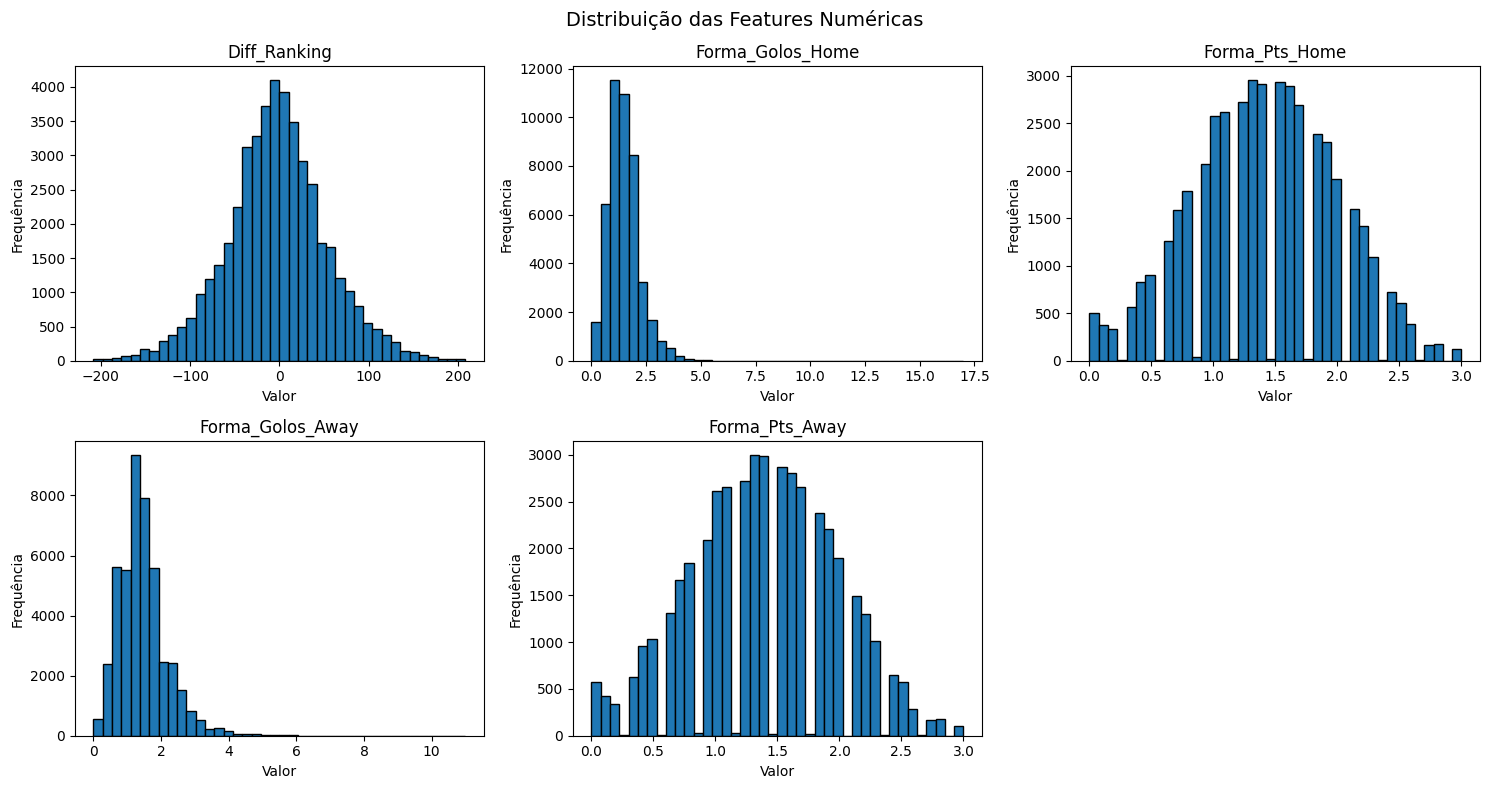

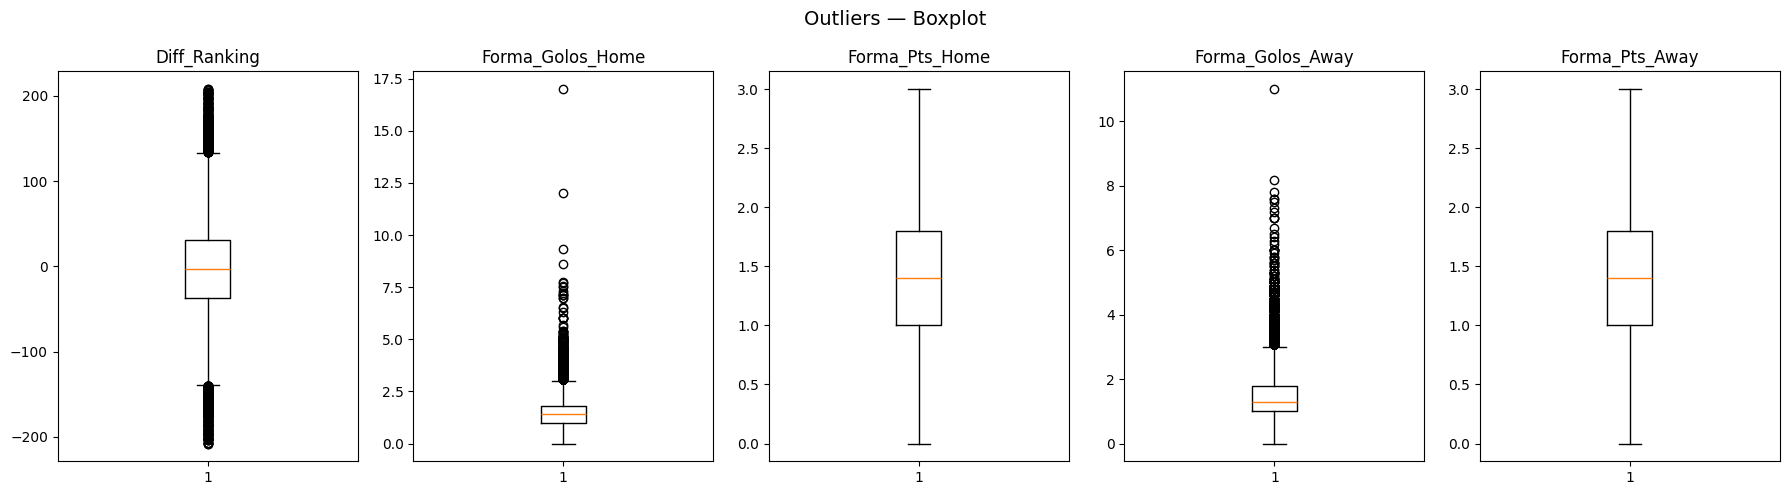

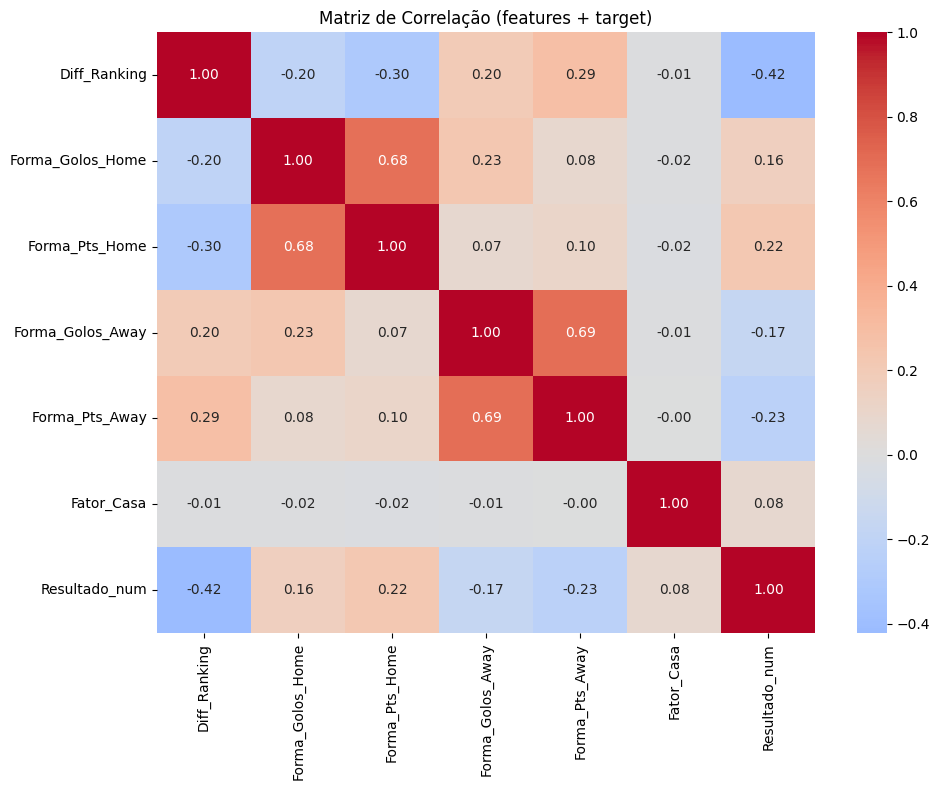

=== Estatísticas Descritivas ===
       Diff_Ranking  Forma_Golos_Home  Forma_Pts_Home  Forma_Golos_Away  \
count     45524.000         45524.000       45524.000         45524.000   
mean         -2.960             1.464           1.398             1.436   
std          55.735             0.716           0.583             0.713   
min        -208.000             0.000           0.000             0.000   
25%         -37.000             1.000           1.000             1.000   
50%          -3.000             1.400           1.400             1.300   
75%          31.000             1.800           1.800             1.800   
max         208.000            17.000           3.000            11.000   

       Forma_Pts_Away  Fator_Casa  
count       45524.000   45524.000  
mean            1.371       0.732  
std             0.585       0.443  
min             0.000       0.000  
25%             1.000       0.000  
50%             1.400       1.000  
75%             1.800       1.000  
max

In [ ]:
# --- EDA 1: Distribuição das features numéricas ---
num_features = [
    "Diff_Ranking", "Forma_Golos_Home", "Forma_Pts_Home",
    "Forma_Golos_Away", "Forma_Pts_Away"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df_train[col].dropna(), bins=40, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")
axes[-1].axis("off")
plt.suptitle("Distribuição das Features Numéricas", fontsize=14)
plt.tight_layout()
plt.show()

# --- EDA 2: Outliers via boxplot ---
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_features):
    axes[i].boxplot(df_train[col].dropna())
    axes[i].set_title(col)
plt.suptitle("Outliers — Boxplot", fontsize=14)
plt.tight_layout()
plt.show()

# --- EDA 3: Correlação entre features e target ---
df_corr = df_train.copy()
df_corr["Resultado_num"] = df_corr["Resultado"].map({"H": 1, "D": 0, "A": -1})
corr = df_corr[num_features + ["Fator_Casa", "Resultado_num"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Matriz de Correlação (features + target)")
plt.tight_layout()
plt.show()

# --- EDA 4: Estatísticas descritivas ---
print("=== Estatísticas Descritivas ===")
print(df_train[num_features + ["Fator_Casa"]].describe().round(3))

print("\n=== Outliers extremos (Diff_Ranking) ===")
q1 = df_train["Diff_Ranking"].quantile(0.01)
q99 = df_train["Diff_Ranking"].quantile(0.99)
print(f"  P1:  {q1:.0f}")
print(f"  P99: {q99:.0f}")
outliers = df_train[
    (df_train["Diff_Ranking"] < q1) | (df_train["Diff_Ranking"] > q99)
]
print(f"  Jogos fora do intervalo P1-P99: {len(outliers)}")

print("\n=== Outliers Forma_Golos (max > 5 golos médios) ===")
golos_outliers = df_train[
    (df_train["Forma_Golos_Home"] > 5) | (df_train["Forma_Golos_Away"] > 5)
]
print(f"  Registos: {len(golos_outliers)}")
print(golos_outliers[["home_team", "away_team", "Forma_Golos_Home", "Forma_Golos_Away"]].head(10).to_string())

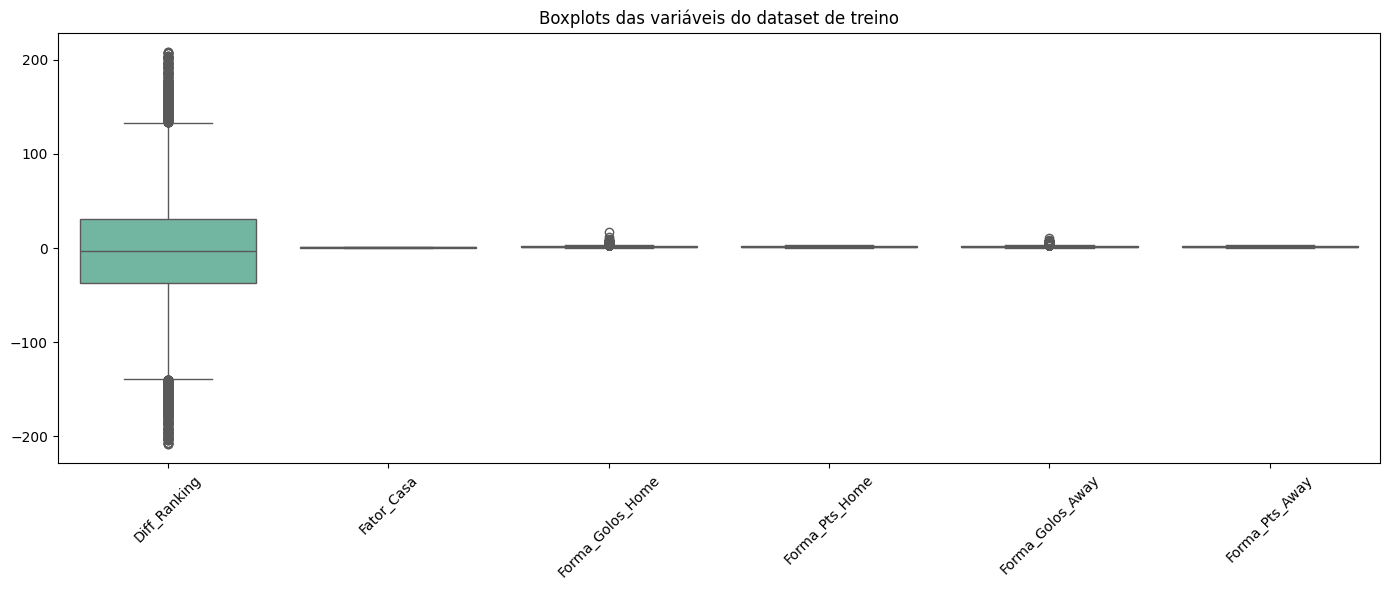

In [6]:
# Selecionar apenas variáveis numéricas relevantes
numeric_cols = [
    "Diff_Ranking",
    "Fator_Casa",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_train[numeric_cols], palette="Set2")
plt.title("Boxplots das variáveis do dataset de treino")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# --- Tratamento de Outliers ---
# Diff_Ranking:  RobustScaler no preprocessador trata os extremos
# Forma_Golos: cap a 5 para eliminar médias irreais do futebol histórico (ex: Denmark 17.0)

# Diagnóstico
print("Antes do cap:")
print(f"  Forma_Golos_Home > 5: {(df_train['Forma_Golos_Home'] > 5).sum()}")
print(f"  Forma_Golos_Away > 5: {(df_train['Forma_Golos_Away'] > 5).sum()}")

GOLOS_CAP = 5.0
for col in ["Forma_Golos_Home", "Forma_Golos_Away"]:
    df_train[col] = df_train[col].clip(upper=GOLOS_CAP)
    df_test[col]  = df_test[col].clip(upper=GOLOS_CAP)

print("\nDepois do cap:")
print(f"  Forma_Golos_Home > 5: {(df_train['Forma_Golos_Home'] > 5).sum()}")
print(f"  Forma_Golos_Away > 5: {(df_train['Forma_Golos_Away'] > 5).sum()}")

Antes do cap:
  Forma_Golos_Home > 5: 38
  Forma_Golos_Away > 5: 50

Depois do cap:
  Forma_Golos_Home > 5: 0
  Forma_Golos_Away > 5: 0


In [ ]:
# --- 1. Carregar dados ---
df_train = pd.read_csv("df_train.csv")
df_full  = pd.read_csv("df_full.csv")
df_full["date"] = pd.to_datetime(df_full["date"])

# --- 2. Conjunto de teste (dinâmico) ---
df_test = df_full[
    (df_full["tournament"] == "FIFA World Cup") &
    (df_full["date"] >= "2026-06-11") &
    (df_full["home_score"].notna())
].copy()

print(f"Treino: {len(df_train)} jogos")
print(f"Teste:  {len(df_test)} jogos")

# --- 3. Features e targets ---
FEATURES_NUM = [
    "Diff_Ranking",
    "Fator_Casa",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away",
]
FEATURES_CAT = ["Tipo_Competicao"]
FEATURES     = FEATURES_NUM + FEATURES_CAT

X_train      = df_train[FEATURES]
y_clf        = df_train["Resultado"]
y_reg_home   = df_train["home_score"]
y_reg_away   = df_train["away_score"]

X_test = df_test[FEATURES]
y_test = df_test.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)

# --- 4. Preprocessador ---
preprocessor = ColumnTransformer(transformers=[
    ("ohe",    OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ("scaler", RobustScaler(),                         FEATURES_NUM),
])

# --- 5. Modelos de Classificação ---
clf_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
clf_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

clf_lr.fit(X_train, y_clf)
clf_rf.fit(X_train, y_clf)

# --- 6. Avaliação Classificação ---
baseline_acc = accuracy_score(y_test, ["H"] * len(y_test))
print(f"\nBaseline naive (sempre H): {baseline_acc:.3f} ({int(baseline_acc*len(y_test))}/{len(y_test)})")

for name, model in [("Logistic Regression", clf_lr), ("Random Forest", clf_rf)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc     = accuracy_score(y_test, y_pred)
    ll      = log_loss(y_test, y_proba, labels=model.classes_)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  Accuracy:  {acc:.3f}  ({int(acc*len(y_test))}/{len(y_test)} corretos)")
    print(f"  Log-loss:  {ll:.3f}")
    print(classification_report(y_test, y_pred, target_names=["A", "D", "H"]))

# --- 7. Modelos de Regressão (Poisson) ---
reg_home = Pipeline([
    ("pre", preprocessor),
    ("reg", PoissonRegressor(max_iter=1000))
])
reg_away = Pipeline([
    ("pre", preprocessor),
    ("reg", PoissonRegressor(max_iter=1000))
])

reg_home.fit(X_train, y_reg_home)
reg_away.fit(X_train, y_reg_away)

# --- 8. Avaliação Regressão ---
pred_home = reg_home.predict(X_test).round(1)
pred_away = reg_away.predict(X_test).round(1)

print("\n=== Regressão Poisson — Previsões vs Real ===")
comparison = pd.DataFrame({
    "home_team": df_test["home_team"].values,
    "away_team": df_test["away_team"].values,
    "real":      df_test["home_score"].astype(int).astype(str) + "-" + df_test["away_score"].astype(int).astype(str),
    "previsto":  pred_home.astype(str) + "-" + pred_away.astype(str),
})
print(comparison.to_string(index=False))

# --- 9. Guardar modelos ---
joblib.dump(clf_lr,   "model_clf_lr.pkl")
joblib.dump(clf_rf,   "model_clf_rf.pkl")
joblib.dump(reg_home, "model_reg_home.pkl")
joblib.dump(reg_away, "model_reg_away.pkl")
print("\nModelos guardados.")

Treino: 45524 jogos
Teste:  28 jogos

Baseline naive (sempre H): 0.536 (15/28)

Logistic Regression
  Accuracy:  0.571  (16/28 corretos)
  Log-loss:  0.988
              precision    recall  f1-score   support

           A       0.38      1.00      0.55         3
           D       0.00      0.00      0.00        10
           H       0.65      0.87      0.74        15

    accuracy                           0.57        28
   macro avg       0.34      0.62      0.43        28
weighted avg       0.39      0.57      0.46        28



C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


Random Forest
  Accuracy:  0.500  (14/28 corretos)
  Log-loss:  0.966
              precision    recall  f1-score   support

           A       0.43      1.00      0.60         3
           D       0.33      0.10      0.15        10
           H       0.56      0.67      0.61        15

    accuracy                           0.50        28
   macro avg       0.44      0.59      0.45        28
weighted avg       0.46      0.50      0.44        28


=== Regressão Poisson — Previsões vs Real ===
     home_team              away_team real previsto
        Mexico           South Africa  2-0  1.9-0.9
   South Korea         Czech Republic  2-1  1.6-1.2
        Canada Bosnia and Herzegovina  1-1  1.7-1.1
 United States               Paraguay  4-1  1.9-1.0
         Qatar            Switzerland  1-1  1.1-1.6
        Brazil                Morocco  1-1  1.6-1.3
         Haiti               Scotland  0-1  1.3-1.5
     Australia                 Turkey  2-0  1.3-1.4
       Germany                Cur